Loading Atlanta Hawks 2025-26 season data...
Loaded 82 games successfully.

  Atlanta Hawks — 2025-26 Season
  Overall:     46W - 36L  (56.1%)
  Home:        24W - 17L  (58.5%)
  Away:        22W - 19L  (53.7%)
  Avg Points:  118.5 per game
  High Score:  150 pts
  Low Score:   86 pts
  Best Stretch:124.9 pts (10-game peak)
  Worst Stretch:111.2 pts (10-game low)



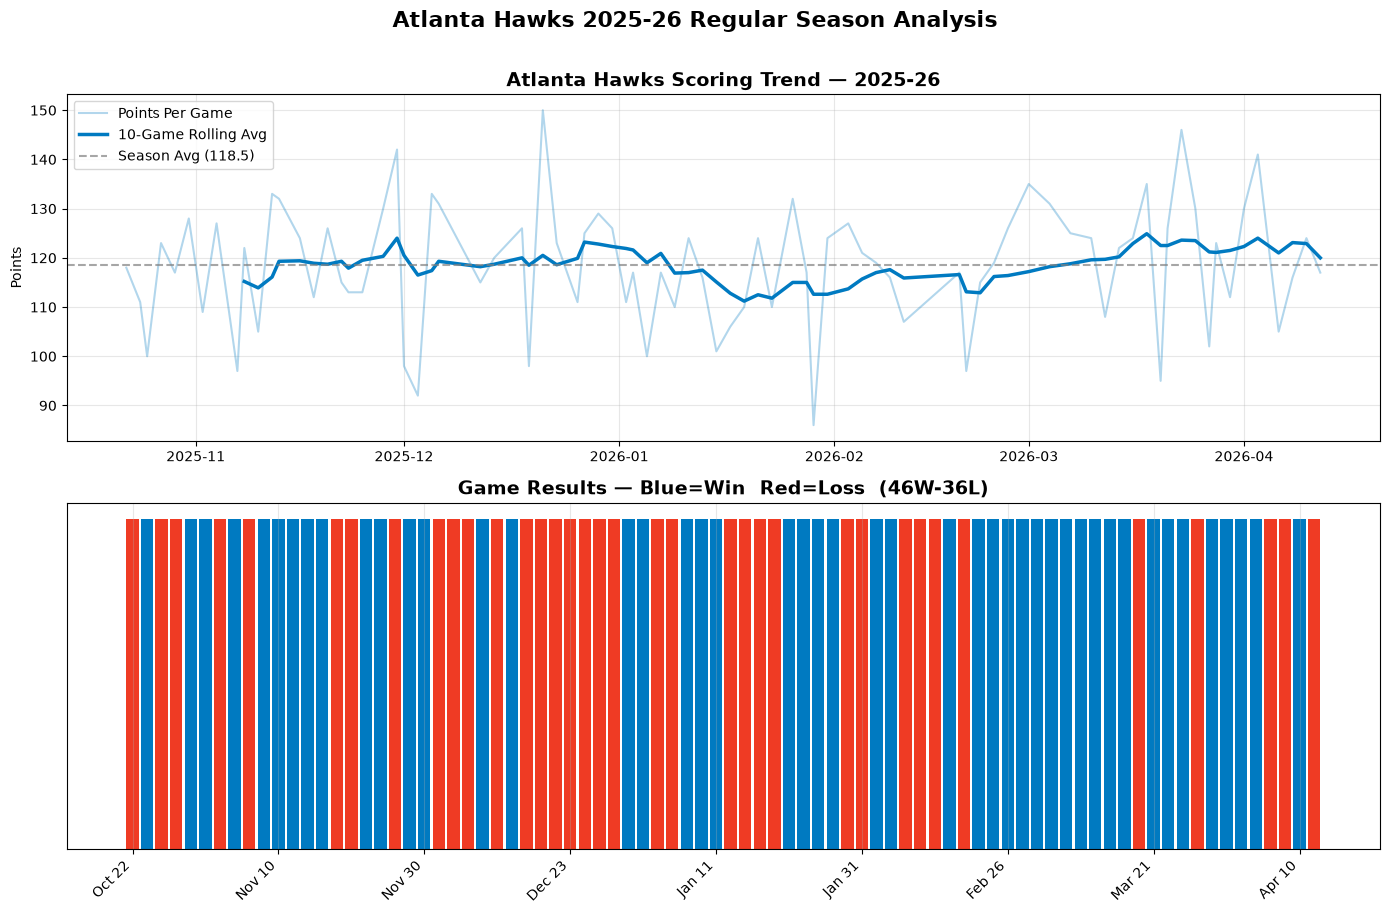

Chart saved as ATL_2025-26_analysis.png


In [11]:
# Cell 1 — Imports
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import teamgamelog
from nba_api.stats.static import teams
import time

# Cell 2 — Team selector function
def get_team_id(team_input):
    """
    Accept team name, city, or abbreviation
    Examples: 'Thunder', 'OKC', 'Oklahoma City'
    """
    all_teams = teams.get_teams()
    team_input = team_input.strip().lower()
    
    for team in all_teams:
        if (team_input in team['full_name'].lower() or
            team_input in team['nickname'].lower() or
            team_input in team['city'].lower() or
            team_input == team['abbreviation'].lower()):
            return team
    
    # If no match found show available teams
    print("Team not found. Available teams:")
    for t in sorted(all_teams, key=lambda x: x['full_name']):
        print(f"  {t['abbreviation']} — {t['full_name']}")
    return None

# Cell 3 — Season selector and data loader
def load_team_data(team_name, season='2025-26'):
    """
    Load game log for any team and season
    Season format: '2024-25', '2023-24', etc.
    """
    team = get_team_id(team_name)
    if not team:
        return None, None
    
    print(f"Loading {team['full_name']} {season} season data...")
    time.sleep(1)  # API rate limit
    
    gamelog = teamgamelog.TeamGameLog(
        team_id=team['id'],
        season=season,
        season_type_all_star='Regular Season'
    )
    
    df = gamelog.get_data_frames()[0]
    df['WL_binary'] = df['WL'].map({'W': 1, 'L': 0})
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'], format='mixed')
    df = df.sort_values('GAME_DATE').reset_index(drop=True)
    df['PTS_rolling'] = df['PTS'].rolling(window=10).mean()
    
    print(f"Loaded {len(df)} games successfully.")
    return df, team

# Cell 4 — Analysis function
def analyze_team(team_name, season='2024-25'):
    """
    Full analysis for any team and season
    """
    df, team = load_team_data(team_name, season)
    if df is None:
        return
    
    # ── Key Stats ─────────────────────────────────
    wins = int(df['WL_binary'].sum())
    losses = int(len(df) - wins)
    win_pct = wins / len(df)
    
    home = df[df['MATCHUP'].str.contains(r'vs\.')]
    away = df[df['MATCHUP'].str.contains(r'@')]
    
    home_wins = int(home['WL_binary'].sum())
    home_losses = int(len(home) - home_wins)
    away_wins = int(away['WL_binary'].sum())
    away_losses = int(len(away) - away_wins)
    
    # ── Print Summary ──────────────────────────────
    print(f"\n{'='*45}")
    print(f"  {team['full_name']} — {season} Season")
    print(f"{'='*45}")
    print(f"  Overall:     {wins}W - {losses}L  ({win_pct:.1%})")
    print(f"  Home:        {home_wins}W - {home_losses}L  ({home_wins/len(home):.1%})")
    print(f"  Away:        {away_wins}W - {away_losses}L  ({away_wins/len(away):.1%})")
    print(f"  Avg Points:  {df['PTS'].mean():.1f} per game")
    print(f"  High Score:  {df['PTS'].max()} pts")
    print(f"  Low Score:   {df['PTS'].min()} pts")
    print(f"  Best Stretch:{df['PTS_rolling'].max():.1f} pts (10-game peak)")
    print(f"  Worst Stretch:{df['PTS_rolling'].min():.1f} pts (10-game low)")
    print(f"{'='*45}\n")
    
    # ── Visualizations ─────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    team_color = '#007AC1'  # Default blue
    
    # Top chart — Scoring trend
    axes[0].plot(df['GAME_DATE'], df['PTS'],
                 alpha=0.3, color=team_color, 
                 label='Points Per Game')
    axes[0].plot(df['GAME_DATE'], df['PTS_rolling'],
                 color=team_color, linewidth=2.5,
                 label='10-Game Rolling Avg')
    axes[0].axhline(y=df['PTS'].mean(), 
                    color='gray', linestyle='--', 
                    alpha=0.7, label=f"Season Avg ({df['PTS'].mean():.1f})")
    axes[0].set_title(
        f"{team['full_name']} Scoring Trend — {season}", 
        fontsize=14, fontweight='bold'
    )
    axes[0].set_ylabel('Points')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Bottom chart — Win/Loss bars
    colors = ['#007AC1' if w == 1 else '#EF3B24' 
              for w in df['WL_binary']]
    axes[1].bar(range(len(df)), [1] * len(df),
                color=colors, width=0.85, edgecolor='none')
    
    tick_positions = range(0, len(df), 10)
    tick_labels = df['GAME_DATE'].iloc[::10].dt.strftime('%b %d')
    axes[1].set_xticks(tick_positions)
    axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')
    axes[1].set_title(
        f'Game Results — Blue=Win  Red=Loss  '
        f'({wins}W-{losses}L)', 
        fontsize=14, fontweight='bold'
    )
    axes[1].set_yticks([])
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.suptitle(
        f"{team['full_name']} {season} Regular Season Analysis",
        fontsize=16, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    
    filename = f"{team['abbreviation']}_{season}_analysis.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved as {filename}")
    
    return df

# Cell 5 — Run it for any team
# Change these two values to analyze any team or season

TEAM = "Atlanta"        # Try: "Lakers", "Warriors", "Celtics", "OKC"
SEASON = "2025-26"      # Try: "2023-24", "2022-23"

df = analyze_team(TEAM, SEASON)